# Numeric Rank

Investigate the eigenvalues of cosine similarity matrix. Will tell us how many clusters there are.

In [1]:
import pandas as pd
import numpy as np
import pickle
import torch
import tiktoken
import requests
import io
from model import GPTConfig, GPT


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/isabella_zhu/urop/website/envtest/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/isabella_zhu/urop/website/envtest/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/isabella_zhu/urop/website/envtest/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739,

In [2]:
num_layers = 7
emb_dim = 384
url = "https://www.dropbox.com/scl/fi/ocaovecmf7che47p1pn0o/ckpt.pt?rlkey=lpfz7b1e5k26ypuw6gltocxub&st=mt9nen3h&dl=1"

In [4]:
def load_model():
    response = requests.get(url, stream=True)
    response.raise_for_status()  # Ensure the request was successful
    checkpoint = torch.load(io.BytesIO(response.content), map_location="cpu")

    # Load the model directly from memory (RAM)
    # ckpt_path = os.path.join('out-tinystories', 'ckpt.pt')
    # checkpoint = torch.load(ckpt_path, map_location=torch.device("cpu"))  # Ensure model loads on CPU
    
    gptconf = GPTConfig(**checkpoint['model_args'])
    model = GPT(gptconf)
    model.to("cpu")  # Move model to CPU
    state_dict = checkpoint['model']

    # Remove unwanted prefixes in state dict
    unwanted_prefix = '_orig_mod.'
    for k in list(state_dict.keys()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)

    model.load_state_dict(state_dict)
    model.eval()  # Set model to evaluation mode
    model.to("cpu")  # Move model to CPU explicitly

    return model

def get_encode_decode():
    enc = tiktoken.get_encoding("gpt2")
    encode = lambda s: enc.encode(s, allowed_special={"<|endoftext|>"})
    decode = lambda l: enc.decode(l)
    return encode, decode


In [5]:
model = load_model()
encode, decode = get_encode_decode()

number of parameters: 29.94M


In [6]:
def get_embeddings(text):
    start_ids = encode(text)
    x = torch.tensor(start_ids, dtype=torch.long, device="cpu")[None, ...]

    embs = model.get_embeddings(x)
    return [emb.detach().cpu().tolist() for emb in embs], [decode([token]) for token in start_ids]

## loading data

In [7]:
from datasets import load_dataset

In [8]:
# Load the TinyStories dataset
dataset = load_dataset("roneneldan/TinyStories", split="train")

# Get the first 500 training instances
first_500_samples = dataset.select(range(500))

## processing

In [14]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [10]:
eigendata = [ [] for i in range(7) ]

In [15]:
for idx, sample in enumerate(first_500_samples):
    if idx % 10 == 0:
        print(f"working on sample {idx}...")
    text_prompt = sample['text']
    all_embs = get_embeddings(text_prompt)
    for layer, layer_embs in enumerate(all_embs[0]):
        # Calculate cosine similarity matrix A
        A = cosine_similarity(layer_embs)

        # Get the eigenvalues of A
        eigenvalues, _ = np.linalg.eig(A)
        numeric_rank = np.sum(np.abs(eigenvalues)) / np.max(np.abs(eigenvalues))

        eigendata[layer].append(numeric_rank)

working on sample 0...
working on sample 10...
working on sample 20...
working on sample 30...
working on sample 40...
working on sample 50...
working on sample 60...
working on sample 70...
working on sample 80...
working on sample 90...
working on sample 100...
working on sample 110...
working on sample 120...
working on sample 130...
working on sample 140...
working on sample 150...
working on sample 160...
working on sample 170...
working on sample 180...
working on sample 190...
working on sample 200...
working on sample 210...
working on sample 220...
working on sample 230...
working on sample 240...
working on sample 250...
working on sample 260...
working on sample 270...
working on sample 280...
working on sample 290...
working on sample 300...
working on sample 310...
working on sample 320...
working on sample 330...
working on sample 340...
working on sample 350...
working on sample 360...
working on sample 370...
working on sample 380...
working on sample 390...
working on 

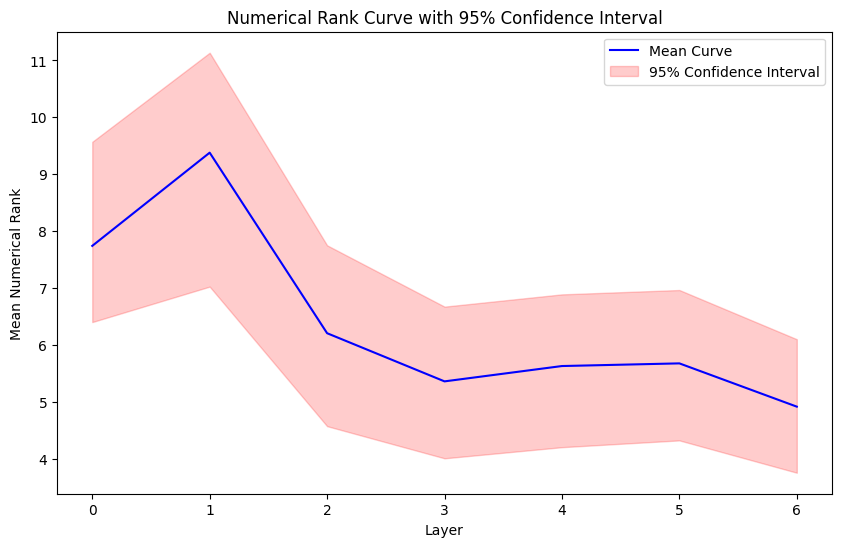

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Assuming eigendata is a list of 7 lists, each containing 500 points
data = np.array(eigendata)  # Shape (7, 500)

# Compute the mean curve across layers (average each column)
mean_curve = np.mean(data, axis=1)  # Shape (500,)

lower_bound = np.percentile(data, 2.5, axis=1)
upper_bound = np.percentile(data, 97.5, axis=1)


# Compute standard error of the mean (SEM) for each index
sem_curve = stats.sem(data, axis=1)  # Shape (500,)

# Degrees of freedom
df = data.shape[1] - 1  # 7 - 1 = 6

# Compute the t-value for a 95% confidence interval
t_value = stats.t.ppf(0.975, df)

# Compute margin of error
margin_error = t_value * sem_curve

# Compute confidence interval bounds
# lower_bound = mean_curve - margin_error
# upper_bound = mean_curve + margin_error

# Define x-axis (index values)
x = np.arange(data.shape[0])  # 0 to 499

# Plot the mean curve with 95% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(x, mean_curve, label='Mean Curve', color='blue')
plt.fill_between(x, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Confidence Interval')
plt.xlabel('Layer')
plt.ylabel('Mean Numerical Rank')
plt.title('Numerical Rank Curve with 95% Confidence Interval')
plt.legend()
plt.show()


In [23]:
import pickle

# Suppose lower_bound, upper_bound, and mean_curve are NumPy arrays computed previously.
data_to_save = {
    'lower_bound': lower_bound,
    'upper_bound': upper_bound,
    'mean_curve': mean_curve
}

# Save the dictionary to a file called 'curve_data.pkl'
with open("numrank_data.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

## messing around

In [11]:
text_prompt = '''
Once upon a time, there was a big octopus. He lived in the deep blue sea. He had a friend, a reliable fish. They played together every day. One day, the octopus and the fish found a big jug. They wanted to pour water on their friends for fun. But they couldn't agree on who would pour the water. The octopus said, "I want to pour the water!" The fish said, "No, I want to pour the water!" They were not happy. Then, the octopus had an idea. He said, "Let's both pour the water!" The fish liked the idea. They picked up the big jug together and poured water on all their friends. Everyone laughed and had fun. The octopus and the fish were happy again. They learned to share and play together. And they lived happily ever after.
'''

In [12]:
all_embs = get_embeddings(text_prompt)

In [15]:
last_layer_embs = all_embs[0][-1]

In [17]:
np.array(last_layer_embs).shape

(178, 384)

In [11]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [30]:
def eigen(layer_embs):
    # layer_embs is a n by d array
    
    # ... existing code ...
    import numpy as np
    from sklearn.metrics.pairwise import cosine_similarity
    import matplotlib.pyplot as plt

    # Calculate cosine similarity matrix A
    A = cosine_similarity(layer_embs)

    # Get the eigenvalues of A
    eigenvalues, _ = np.linalg.eig(A)

    # Plot the eigenvalues of A in decreasing magnitude
    plt.figure(figsize=(10, 6))
    plt.plot(np.sort(eigenvalues)[::-1], marker='o')
    plt.title('Eigenvalues in Decreasing Magnitude')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid()
    plt.show()

    # Calculate the numeric rank and print it
    numeric_rank = np.sum(np.abs(eigenvalues)) / np.max(np.abs(eigenvalues))
    print(f'Numeric Rank: {numeric_rank}')
    # ... existing code ...

In [35]:
def eigen_investigate(layer_embs):
    # layer_embs is a n by d array
    
    # ... existing code ...
    import numpy as np
    from sklearn.metrics.pairwise import cosine_similarity
    import matplotlib.pyplot as plt

    # Calculate cosine similarity matrix A
    A = cosine_similarity(layer_embs)
    print(A)

    # Get the eigenvalues of A
    eigenvalues, _ = np.linalg.eig(A)

    eigenvalues.sort()
    print("Smallest 10:")
    print(eigenvalues[:10])

In [36]:
eigen_investigate(all_embs[0][2])

[[ 1.          0.76921545  0.71695366 ... -0.00100667  0.02004273
   0.16452819]
 [ 0.76921545  1.          0.82972648 ...  0.03461896 -0.03043522
   0.06554454]
 [ 0.71695366  0.82972648  1.         ...  0.02708723 -0.06274272
   0.0488092 ]
 ...
 [-0.00100667  0.03461896  0.02708723 ...  1.          0.48670127
   0.30918909]
 [ 0.02004273 -0.03043522 -0.06274272 ...  0.48670127  1.
   0.59449155]
 [ 0.16452819  0.06554454  0.0488092  ...  0.30918909  0.59449155
   1.        ]]
Smallest 10:
[0.00067376 0.00078024 0.00080885 0.00113579 0.0011631  0.0012526
 0.0013207  0.00152019 0.00177105 0.00185702]


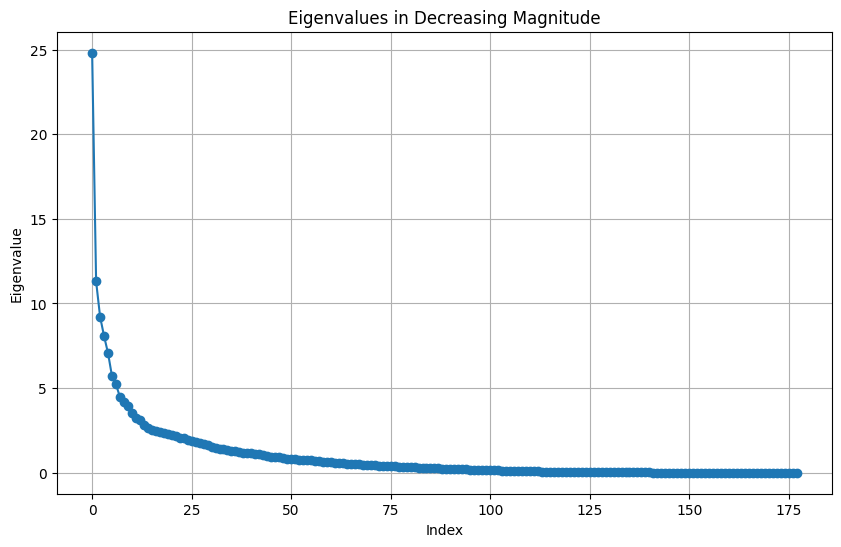

Numeric Rank: 7.174082379020437


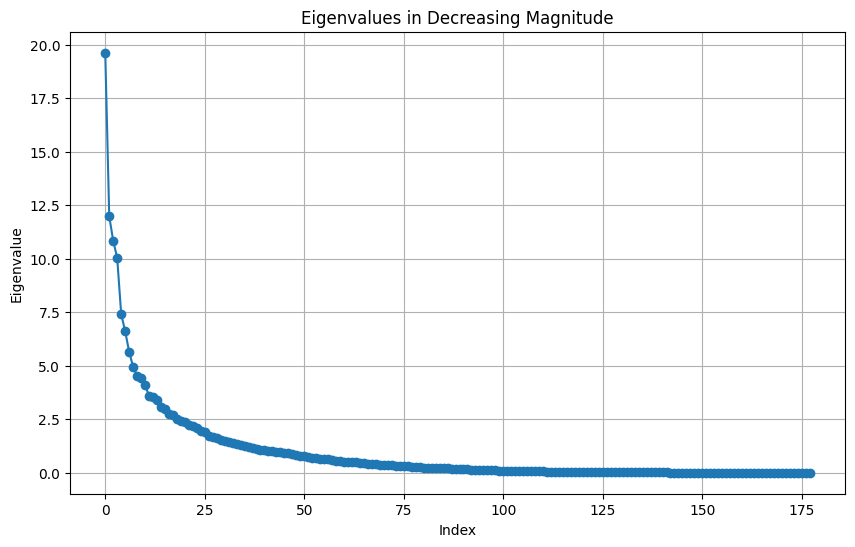

Numeric Rank: 9.07367100401994


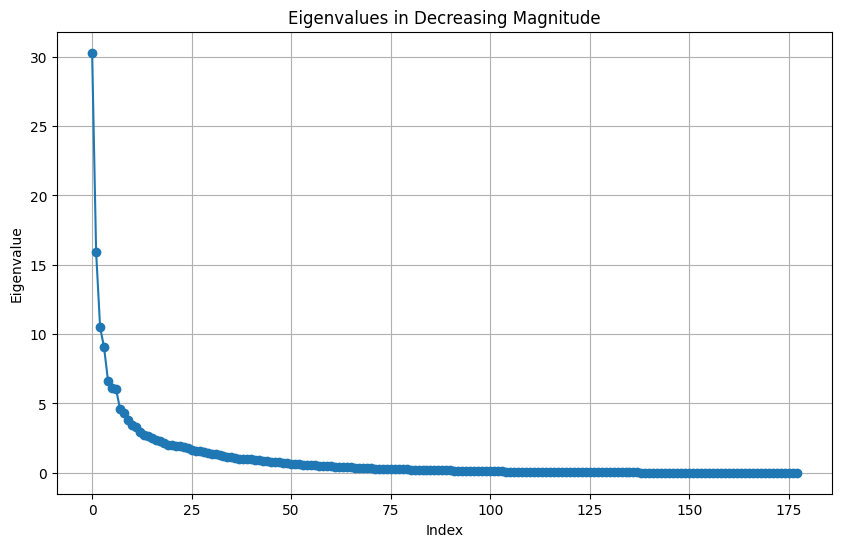

Numeric Rank: 5.875996007934702


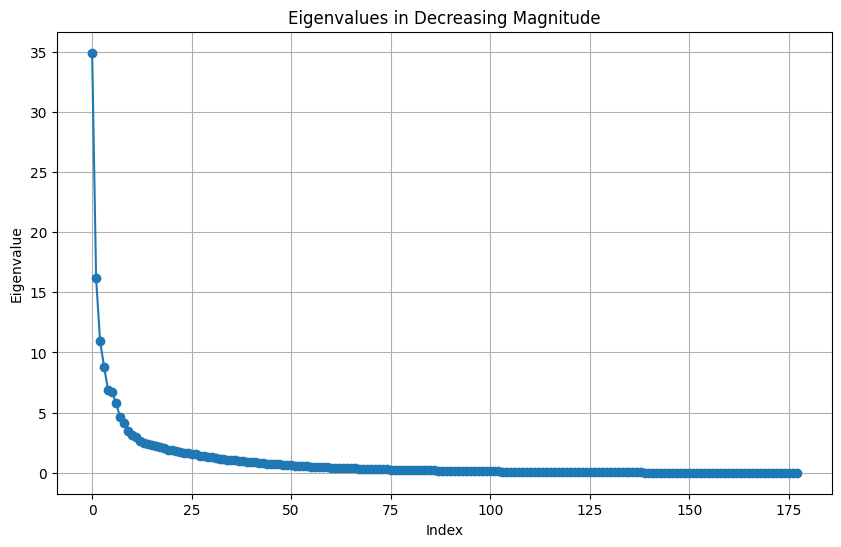

Numeric Rank: 5.098371843453634


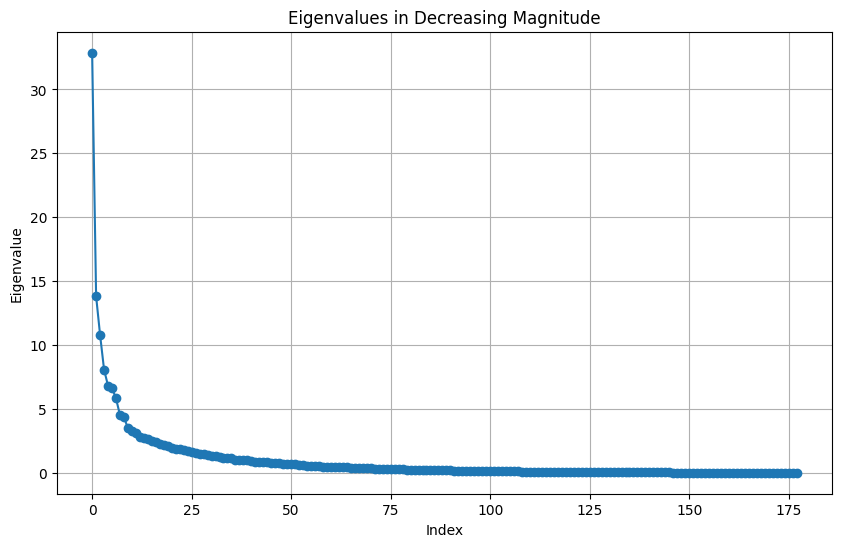

Numeric Rank: 5.414963263215888


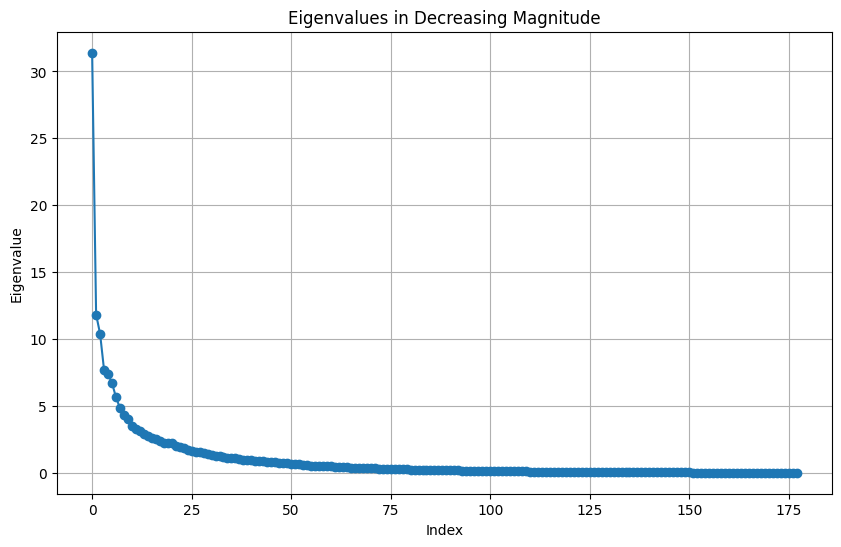

Numeric Rank: 5.668407626132247


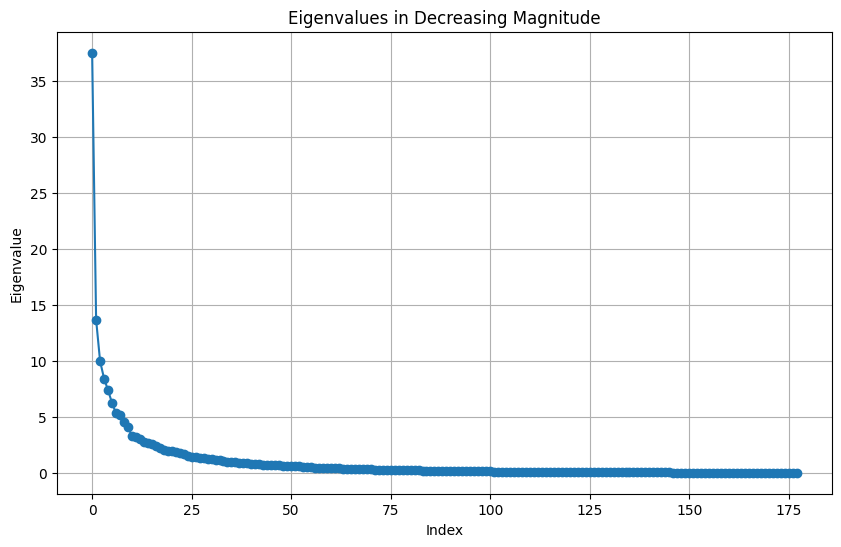

Numeric Rank: 4.747464709600448


In [31]:
for layer_embs in all_embs[0]:
    eigen(layer_embs)